# 0. Título y objetivo del notebook

Este notebook tiene como objetivo automatizar la ejecución de experimentos para estudiar la influencia de distintos hiperparámetros sobre el rendimiento de los modelos predictivos.

En particular, se evaluará el efecto de:

- La proporción de observaciones Sentinel-3 `downscaled` incorporadas al entrenamiento.
- La longitud de ventana temporal empleada por el modelo GCN+GRU.
- La variabilidad producida por distintas semillas aleatorias.

Cada configuración experimental se entrenará varias veces y los resultados se almacenarán automáticamente en ficheros CSV para su posterior análisis estadístico.

# 1. Instalación, imports y conexión con Drive

En esta sección se instalan las dependencias necesarias, se importan las bibliotecas principales y se conecta el entorno de Google Colab con Google Drive.

In [1]:
# ============================================================
# 1. INSTALACIÓN, IMPORTS Y CONEXIÓN CON DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

!pip -q install xgboost optuna optuna-integration torch-geometric

import os
import time
import copy
import random
import gc

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GraphDataLoader
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("CUDA disponible:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.4 MB/s eta 0:00:00
CUDA disponible: True
Device: cuda


# 2. Configuración global

En esta sección se centralizan las rutas, los valores de los hiperparámetros a estudiar, las semillas aleatorias y los parámetros generales de entrenamiento.

Modificar esta celda permite cambiar el comportamiento completo del notebook sin tocar el resto del código.

In [21]:
# ============================================================
# 2. CONFIGURACIÓN GLOBAL
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

SENTINEL_CSV = os.path.join(BASE_PATH, "datos_sentinel_downscalled.csv")
LANDSAT_CSV = os.path.join(BASE_PATH, "datos_landsat.csv")

RESULTS_DIR = os.path.join(BASE_PATH, "experimentos_automatizados")
os.makedirs(RESULTS_DIR, exist_ok=True)

DETAILED_RESULTS_PATH = os.path.join(RESULTS_DIR, "results_detailed.csv")
AGGREGATED_RESULTS_PATH = os.path.join(RESULTS_DIR, "results_aggregated.csv")

MODEL_DIR = os.path.join(RESULTS_DIR, "modelos")
os.makedirs(MODEL_DIR, exist_ok=True)

FIGURES_DIR = os.path.join(RESULTS_DIR, "figuras")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ------------------------------------------------------------
# Parámetros experimentales
# ------------------------------------------------------------

SENTINEL_RATIOS = list(range(0, 9))
SEQ_LENS = [1, 3, 5, 7, 10]

N_SEEDS = 5
SEEDS = [42, 123, 2024, 7, 99][:N_SEEDS]

FIXED_SENTINEL_RATIO = 3
FIXED_SEQ_LEN = 5

FINAL_SENTINEL_RATIO = 3
FINAL_SEQ_LEN = 5

RUN_SENTINEL_RATIO_EXPERIMENT = False
RUN_SEQ_LEN_EXPERIMENT = False
RUN_FINAL_COMPARISON_EXPERIMENT = True


MODELS_SENTINEL_RATIO = [
    "XGBoost",
    "GCN",
    "GCN_GRU"
]

MODELS_SEQ_LEN = [
    "GCN_GRU"
]

MODELS_FINAL_COMPARISON = [
    "XGBoost",
    "GRU",
    "GCN",
    "GraphSAGE",
    "GCN_GRU"
]

# ------------------------------------------------------------
# Columnas
# ------------------------------------------------------------

TARGET_COL = "LST"

FEATURE_COLS = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "DEM",
    "NDBI",
    "ALBEDO",
    "aspect_ratio",
    "has_buildings",
    "row_norm",
    "col_norm",
    "sin_doy",
    "cos_doy",
    "rain_3d_log",
    "is_rainy",
]

BASE_COLS = [
    "source",
    "node_id",
    "date",
    "latitude",
    "longitude",
    "row",
    "col",
    "row_norm",
    "col_norm",
    TARGET_COL,
]

NEEDED_COLS = list(dict.fromkeys(BASE_COLS + FEATURE_COLS))

# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GCN_BATCH_SIZE = 16
GCN_GRU_BATCH_SIZE = 8

MAX_EPOCHS_GCN = 250
PATIENCE_GCN = 30

MAX_EPOCHS_GCN_GRU = 200
PATIENCE_GCN_GRU = 15

print("Configuración cargada correctamente.")
print("Resultados en:", RESULTS_DIR)

Configuración cargada correctamente.
Resultados en: /content/drive/MyDrive/TFM/experimentos_automatizados


# 3. Funciones auxiliares generales

Esta sección contiene funciones reutilizables empleadas a lo largo de todos los experimentos.

Las funciones incluidas permiten:

- Garantizar la reproducibilidad mediante el control de semillas aleatorias.
- Calcular métricas de evaluación homogéneas para todos los modelos.
- Guardar automáticamente los resultados experimentales.
- Liberar memoria entre ejecuciones.
- Generar resúmenes estadísticos de los experimentos realizados.

De este modo se evita duplicar código y se facilita la comparación entre diferentes configuraciones experimentales.

In [3]:
# ============================================================
# 3. FUNCIONES AUXILIARES GENERALES
# ============================================================

def set_global_seed(seed):
    """
    Fija todas las semillas aleatorias relevantes.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def clear_memory():

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
# ============================================================
# MÉTRICAS
# ============================================================

def compute_metrics(y_true, y_pred, eps=1e-8):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                /
                np.maximum(np.abs(y_true), eps)
            )
        )
        * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [5]:
# ============================================================
# GUARDADO DE RESULTADOS
# ============================================================

def save_experiment_result(
    model_name,
    experiment_type,
    sentinel_ratio,
    seq_len,
    seed,
    total_training_time_s,
    n_epochs,
    test_metrics,
    csv_path=DETAILED_RESULTS_PATH
):

    seconds_per_epoch = (
        total_training_time_s / n_epochs
        if n_epochs is not None and n_epochs > 0
        else np.nan
    )

    new_row = pd.DataFrame([{
        "model": model_name,
        "experiment_type": experiment_type,
        "sentinel_ratio": sentinel_ratio,
        "seq_len": seq_len,
        "seed": seed,
        "total_training_time_s": total_training_time_s,
        "n_epochs": n_epochs,
        "seconds_per_epoch": seconds_per_epoch,
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"],
        "test_MAPE": test_metrics["MAPE"]
    }])

    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [old_df, new_row],
            ignore_index=True
        )
    else:
        results_df = new_row

    results_df.to_csv(csv_path, index=False)

In [6]:
# ============================================================
# AGREGAR RESULTADOS
# ============================================================

def aggregate_results():

    df = pd.read_csv(DETAILED_RESULTS_PATH)

    agg_df = (
        df
        .groupby([
            "model",
            "experiment_type",
            "sentinel_ratio",
            "seq_len"
        ])
        .agg({
            "test_MAE": ["mean", "std"],
            "test_RMSE": ["mean", "std"],
            "test_R2": ["mean", "std"],
            "test_MAPE": ["mean", "std"],
            "total_training_time_s": ["mean", "std"]
        })
        .reset_index()
    )

    agg_df.columns = [
        "_".join(col).strip("_")
        for col in agg_df.columns
    ]

    agg_df.to_csv(
        AGGREGATED_RESULTS_PATH,
        index=False
    )

    return agg_df

# 4. Carga de datos base

En esta sección se cargan los conjuntos de datos originales utilizados en los experimentos.

Los datos proceden de dos fuentes principales:

- Landsat 8/9: observaciones reales de temperatura superficial terrestre.
- Sentinel-3 downscaled: observaciones sintéticas generadas mediante el procedimiento de downscaling descrito anteriormente.

Además de la carga inicial, se realiza una normalización básica de formatos y tipos de datos para garantizar la compatibilidad entre ambos conjuntos antes de la fase de preprocesamiento.

In [7]:
# ============================================================
# 4. CARGA DE DATOS BASE
# ============================================================

df_sentinel = pd.read_csv(SENTINEL_CSV)

df_landsat = pd.read_csv(LANDSAT_CSV)

print("Sentinel:", df_sentinel.shape)
print("Landsat :", df_landsat.shape)

Sentinel: (400950, 26)
Landsat : (40539, 26)


In [8]:
# ============================================================
# NORMALIZACIÓN BÁSICA
# ============================================================

def normalize_basic_columns(
    df,
    source_name
):

    df = df.copy()

    df["source"] = source_name

    if "lat" in df.columns:
        df = df.rename(
            columns={"lat": "latitude"}
        )

    if "lon" in df.columns:
        df = df.rename(
            columns={"lon": "longitude"}
        )

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    df["node_id"] = (
        df["node_id"]
        .astype(str)
    )

    return df

In [9]:
# ============================================================
# APLICAR NORMALIZACIÓN
# ============================================================

df_sentinel = normalize_basic_columns(
    df_sentinel,
    "sentinel_downscaled"
)

df_landsat = normalize_basic_columns(
    df_landsat,
    "landsat_original"
)

print(
    df_sentinel["source"].value_counts()
)

print(
    df_landsat["source"].value_counts()
)


source
sentinel_downscaled    400950
Name: count, dtype: int64
source
landsat_original    40539
Name: count, dtype: int64


# 5. Preparación de datasets

Esta sección contiene toda la lógica necesaria para construir los conjuntos de entrenamiento, validación y prueba a partir de Landsat y Sentinel-3 downscaled.

La función principal `prepare_experiment_data()` recibe un `sentinel_ratio` y una semilla, selecciona aleatoriamente las fechas Sentinel correspondientes, construye el split híbrido, ajusta los escaladores únicamente sobre entrenamiento y genera los objetos necesarios para XGBoost, GCN y GCN+GRU.

In [10]:
# ============================================================
# 5. PREPARACIÓN DE DATASETS
# ============================================================

def add_spatial_temporal_features(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["day_of_year"] = df["date"].dt.dayofyear
    df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    node_df = (
        df[["node_id", "latitude", "longitude"]]
        .drop_duplicates("node_id")
        .copy()
    )

    node_df["lat_key"] = node_df["latitude"].round(6)
    node_df["lon_key"] = node_df["longitude"].round(6)

    lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
    lon_vals = np.sort(node_df["lon_key"].unique())

    node_df["row"] = node_df["lat_key"].map({lat: i for i, lat in enumerate(lat_vals)})
    node_df["col"] = node_df["lon_key"].map({lon: j for j, lon in enumerate(lon_vals)})

    node_df["row_norm"] = node_df["row"] / max(len(lat_vals) - 1, 1)
    node_df["col_norm"] = node_df["col"] / max(len(lon_vals) - 1, 1)

    df = df.drop(columns=["row", "col", "row_norm", "col_norm"], errors="ignore")

    df = df.merge(
        node_df[["node_id", "row", "col", "row_norm", "col_norm"]],
        on="node_id",
        how="left",
        validate="many_to_one"
    )

    return df


def check_required_columns(df, name):
    missing = [c for c in NEEDED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {name}: {missing}")


def build_grid_edge_index(node_df):
    node_df = node_df.copy()

    n_rows = node_df["row"].nunique()
    n_cols = node_df["col"].nunique()

    pos_to_nodeid = dict(
        zip(
            zip(node_df["row"].astype(int), node_df["col"].astype(int)),
            node_df["node_id"].astype(str)
        )
    )

    nodeid_to_idx = {
        node_id: i
        for i, node_id in enumerate(node_df["node_id"].astype(str).tolist())
    }

    edges = []
    displacements = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    for _, row in node_df.iterrows():
        node_id = str(row["node_id"])
        r = int(row["row"])
        c = int(row["col"])
        src_idx = nodeid_to_idx[node_id]

        for dr, dc in displacements:
            rr, cc = r + dr, c + dc

            if 0 <= rr < n_rows and 0 <= cc < n_cols:
                neigh_id = pos_to_nodeid.get((rr, cc))

                if neigh_id is not None:
                    dst_idx = nodeid_to_idx[str(neigh_id)]
                    edges.append((src_idx, dst_idx))

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return edge_index, nodeid_to_idx


def build_spatiotemporal_tensor(df, node_df, fill_method="ffill_bfill"):
    df = df.copy()
    df["datetime_key"] = pd.to_datetime(df["date"], errors="coerce")
    df["node_id"] = df["node_id"].astype(str)

    node_order = node_df["node_id"].astype(str).tolist()
    times = np.sort(df["datetime_key"].dropna().unique())

    full_index = pd.MultiIndex.from_product(
        [times, node_order],
        names=["datetime_key", "node_id"]
    )

    work_df = (
        df.set_index(["datetime_key", "node_id"])
        .sort_index()
        .reindex(full_index)
    )

    mask = (
        work_df[FEATURE_COLS]
        .notna()
        .all(axis=1)
        .values
        .reshape(len(times), len(node_order))
    )

    cols_to_fill = FEATURE_COLS + [TARGET_COL]

    if fill_method == "ffill_bfill":
        work_df[cols_to_fill] = (
            work_df[cols_to_fill]
            .groupby(level="node_id")
            .ffill()
            .groupby(level="node_id")
            .bfill()
        )
    elif fill_method == "zero":
        work_df[cols_to_fill] = work_df[cols_to_fill].fillna(0)

    X = work_df[FEATURE_COLS].values.reshape(
        len(times), len(node_order), len(FEATURE_COLS)
    )

    y = work_df[TARGET_COL].values.reshape(
        len(times), len(node_order)
    )

    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(mask, dtype=torch.bool),
        times,
        node_order
    )


def prepare_experiment_data(sentinel_ratio, seed):
    set_global_seed(seed)

    df_s = df_sentinel.copy()
    df_o = df_landsat.copy()

    df_s = add_spatial_temporal_features(df_s)
    df_o = add_spatial_temporal_features(df_o)

    check_required_columns(df_s, "Sentinel downscaled")
    check_required_columns(df_o, "Landsat original")

    df_s = df_s[NEEDED_COLS].copy()
    df_o = df_o[NEEDED_COLS].copy()

    df = pd.concat([df_s, df_o], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")
    df["node_id"] = df["node_id"].astype(str)

    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

    landsat_dates = np.array(
        sorted(df.loc[df["source"] == "landsat_original", "date_str"].unique())
    )

    sentinel_dates_all = np.array(
        sorted(df.loc[df["source"] == "sentinel_downscaled", "date_str"].unique())
    )

    n_landsat = len(landsat_dates)

    train_end = int(0.70 * n_landsat)
    val_end = int(0.85 * n_landsat)

    landsat_train_dates = landsat_dates[:train_end]
    val_dates = landsat_dates[train_end:val_end]
    test_dates = landsat_dates[val_end:]

    n_sentinel_target = min(
        len(sentinel_dates_all),
        int(sentinel_ratio * len(landsat_train_dates))
    )

    rng = np.random.default_rng(seed)

    if n_sentinel_target > 0:
        sentinel_train_dates = np.array(
            sorted(
                rng.choice(
                    sentinel_dates_all,
                    size=n_sentinel_target,
                    replace=False
                )
            )
        )
    else:
        sentinel_train_dates = np.array([])

    train_dates = np.array(
        sorted(
            np.concatenate([
                landsat_train_dates,
                sentinel_train_dates
            ])
        )
    )

    train_mask = (
        (
            (df["source"] == "landsat_original") &
            (df["date_str"].isin(landsat_train_dates))
        )
        |
        (
            (df["source"] == "sentinel_downscaled") &
            (df["date_str"].isin(sentinel_train_dates))
        )
    )

    val_mask = (
        (df["source"] == "landsat_original") &
        (df["date_str"].isin(val_dates))
    )

    test_mask = (
        (df["source"] == "landsat_original") &
        (df["date_str"].isin(test_dates))
    )

    train_df = df.loc[train_mask].copy()
    val_df = df.loc[val_mask].copy()
    test_df = df.loc[test_mask].copy()

    scaler_X = StandardScaler()
    scaler_X.fit(train_df[FEATURE_COLS])

    scaler_y = StandardScaler()
    scaler_y.fit(train_df[[TARGET_COL]])

    df_scaled = df.copy()
    df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
    df_scaled.loc[:, [TARGET_COL]] = scaler_y.transform(df[[TARGET_COL]])

    node_df = (
        df_o[["node_id", "latitude", "longitude", "row", "col"]]
        .drop_duplicates("node_id")
        .sort_values("node_id")
        .reset_index(drop=True)
    )

    edge_index, nodeid_to_idx = build_grid_edge_index(node_df)

    X, y, mask, dates, node_order = build_spatiotemporal_tensor(
        df_scaled,
        node_df
    )

    date_strings = pd.to_datetime(dates).strftime("%Y-%m-%d")

    train_time_idx = np.where(np.isin(date_strings, train_dates))[0]
    val_time_idx = np.where(np.isin(date_strings, val_dates))[0]
    test_time_idx = np.where(np.isin(date_strings, test_dates))[0]

    print("\n==============================")
    print("DATASET EXPERIMENTAL")
    print("==============================")
    print("Sentinel Ratio:", sentinel_ratio)
    print("Seed:", seed)
    print("Landsat train:", len(landsat_train_dates))
    print("Sentinel train:", len(sentinel_train_dates))
    print("Val Landsat:", len(val_dates))
    print("Test Landsat:", len(test_dates))
    print("Train filas:", train_df.shape)
    print("Val filas:", val_df.shape)
    print("Test filas:", test_df.shape)
    print("Tensor X:", tuple(X.shape))
    print("edge_index:", tuple(edge_index.shape))

    return {
        "df": df,
        "df_scaled": df_scaled,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,

        "X_train": train_df[FEATURE_COLS],
        "y_train": train_df[TARGET_COL],
        "X_val": val_df[FEATURE_COLS],
        "y_val": val_df[TARGET_COL],
        "X_test": test_df[FEATURE_COLS],
        "y_test": test_df[TARGET_COL],

        "X": X,
        "y": y,
        "mask": mask,
        "dates": dates,
        "node_df": node_df,
        "node_order": node_order,
        "edge_index": edge_index,

        "train_time_idx": train_time_idx,
        "val_time_idx": val_time_idx,
        "test_time_idx": test_time_idx,

        "scaler_X": scaler_X,
        "scaler_y": scaler_y,

        "landsat_train_dates": landsat_train_dates,
        "sentinel_train_dates": sentinel_train_dates,
        "val_dates": val_dates,
        "test_dates": test_dates,
        "train_dates": train_dates
    }


class SpatioTemporalWindowDataset(Dataset):
    def __init__(self, X, y, mask, target_time_indices, seq_len):
        self.X = X
        self.y = y
        self.mask = mask
        self.seq_len = seq_len
        self.samples = []

        for t in sorted(list(target_time_indices)):
            start = t - seq_len + 1
            end = t + 1

            if start >= 0:
                self.samples.append((list(range(start, end)), t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        context, target_t = self.samples[idx]

        return {
            "x_seq": self.X[context],
            "y": self.y[target_t],
            "mask": self.mask[target_t],
            "target_t": target_t
        }


def create_gcn_graph_loaders(exp_data, batch_size=GCN_BATCH_SIZE):
    dates_str = pd.to_datetime(exp_data["dates"]).strftime("%Y-%m-%d").to_numpy()

    train_set = set(pd.to_datetime(exp_data["train_dates"]).strftime("%Y-%m-%d"))
    val_set = set(pd.to_datetime(exp_data["val_dates"]).strftime("%Y-%m-%d"))
    test_set = set(pd.to_datetime(exp_data["test_dates"]).strftime("%Y-%m-%d"))

    graphs = []

    for t in range(exp_data["X"].shape[0]):
        g = Data(
            x=exp_data["X"][t],
            y=exp_data["y"][t],
            edge_index=exp_data["edge_index"]
        )
        g.node_mask = exp_data["mask"][t]
        g.date = dates_str[t]
        graphs.append(g)

    train_graphs = [g for g in graphs if g.date in train_set]
    val_graphs = [g for g in graphs if g.date in val_set]
    test_graphs = [g for g in graphs if g.date in test_set]

    return (
        GraphDataLoader(train_graphs, batch_size=batch_size, shuffle=True),
        GraphDataLoader(val_graphs, batch_size=batch_size, shuffle=False),
        GraphDataLoader(test_graphs, batch_size=batch_size, shuffle=False)
    )


def create_gcngru_loaders(exp_data, seq_len, batch_size=GCN_GRU_BATCH_SIZE):
    train_dataset = SpatioTemporalWindowDataset(
        exp_data["X"], exp_data["y"], exp_data["mask"],
        exp_data["train_time_idx"], seq_len
    )

    val_dataset = SpatioTemporalWindowDataset(
        exp_data["X"], exp_data["y"], exp_data["mask"],
        exp_data["val_time_idx"], seq_len
    )

    test_dataset = SpatioTemporalWindowDataset(
        exp_data["X"], exp_data["y"], exp_data["mask"],
        exp_data["test_time_idx"], seq_len
    )

    print("Ventanas train:", len(train_dataset))
    print("Ventanas val:", len(val_dataset))
    print("Ventanas test:", len(test_dataset))

    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )




def create_gru_baseline_arrays(exp_data, seq_len):
    X = exp_data["X"].numpy()
    y = exp_data["y"].numpy()
    mask = exp_data["mask"].numpy()

    def build_arrays(time_indices):
        X_samples = []
        y_samples = []

        for t in sorted(list(time_indices)):
            start = t - seq_len + 1
            end = t + 1

            if start < 0:
                continue

            for node_idx in range(X.shape[1]):
                if mask[t, node_idx]:
                    X_samples.append(X[start:end, node_idx, :])
                    y_samples.append(y[t, node_idx])

        return np.array(X_samples), np.array(y_samples)

    X_train, y_train = build_arrays(exp_data["train_time_idx"])
    X_val, y_val = build_arrays(exp_data["val_time_idx"])
    X_test, y_test = build_arrays(exp_data["test_time_idx"])

    return X_train, y_train, X_val, y_val, X_test, y_test

# 6. Funciones de modelos

En esta sección se definen las arquitecturas y funciones de construcción de modelos.

Se incluyen tres familias principales:

- `XGBoost`, como baseline tabular.
- `GCN`, como modelo espacial basado en grafos.
- `GCN+GRU`, como modelo híbrido espacio-temporal.

Estas funciones únicamente construyen los modelos. El entrenamiento y la evaluación se implementarán en las secciones posteriores.

In [11]:
# ============================================================
# 6. FUNCIONES DE MODELOS
# ============================================================

def build_xgboost_model(seed, params=None):
    if params is None:
        params = {
            "n_estimators": 800,
            "learning_rate": 0.03,
            "max_depth": 5,
            "min_child_weight": 5,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "gamma": 0.0,
            "reg_alpha": 0.01,
            "reg_lambda": 1.0,
        }

    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=seed,
        early_stopping_rounds=50
    )

    return model


class GCNRegressorResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.20):
        super().__init__()

        self.input_proj = nn.Linear(in_channels, hidden_channels)

        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index

        x0 = self.input_proj(x)

        h = self.conv1(x0, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)

        h = h + x0

        h = F.dropout(h, p=self.dropout, training=self.training)

        return self.head(h).squeeze(-1)


def build_gcn_model(in_channels):
    return GCNRegressorResidual(
        in_channels=in_channels,
        hidden_channels=64,
        dropout=0.20
    ).to(DEVICE)


def drop_edge(edge_index, drop_prob=0.15, training=True):
    if (not training) or drop_prob <= 0:
        return edge_index

    num_edges = edge_index.size(1)
    keep_mask = torch.rand(num_edges, device=edge_index.device) > drop_prob

    return edge_index[:, keep_mask]


class Regularized_GCN_GRU_LSTPredictor(nn.Module):
    def __init__(
        self,
        in_channels,
        gcn_hidden=64,
        gru_hidden=64,
        dropout=0.20,
        edge_dropout=0.05
    ):
        super().__init__()

        self.edge_dropout = edge_dropout
        self.dropout = dropout

        self.gcn1 = GCNConv(in_channels, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)

        self.norm1 = nn.LayerNorm(gcn_hidden)
        self.norm2 = nn.LayerNorm(gcn_hidden)

        self.gru = nn.GRU(
            input_size=gcn_hidden,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True
        )

        self.temporal_norm = nn.LayerNorm(gru_hidden)

        self.head = nn.Sequential(
            nn.Linear(gru_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def encode_graph(self, x_t, edge_index):
        edge_index_used = drop_edge(
            edge_index,
            drop_prob=self.edge_dropout,
            training=self.training
        )

        h = self.gcn1(x_t, edge_index_used)
        h = self.norm1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.gcn2(h, edge_index_used)
        h = self.norm2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        return h

    def forward(self, x_seq, edge_index):
        B, S, N, F_in = x_seq.shape

        temporal_embeddings = []

        for s in range(S):
            x_t = x_seq[:, s]

            batch_emb = []

            for b in range(B):
                h = self.encode_graph(x_t[b], edge_index)
                batch_emb.append(h)

            batch_emb = torch.stack(batch_emb, dim=0)
            temporal_embeddings.append(batch_emb)

        h_seq = torch.stack(temporal_embeddings, dim=2)
        h_seq = h_seq.reshape(B * N, S, -1)

        gru_out, _ = self.gru(h_seq)

        last_h = gru_out[:, -1, :]
        last_h = self.temporal_norm(last_h)

        pred = self.head(last_h).reshape(B, N)

        return pred


def build_gcngru_model(in_channels):
    return Regularized_GCN_GRU_LSTPredictor(
        in_channels=in_channels,
        gcn_hidden=64,
        gru_hidden=64,
        dropout=0.20,
        edge_dropout=0.05
    ).to(DEVICE)


from torch_geometric.nn import SAGEConv

class GraphSAGERegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.25):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.head(x).squeeze(-1)


def build_graphsage_model(in_channels):
    return GraphSAGERegressor(
        in_channels=in_channels,
        hidden_channels=64,
        dropout=0.25
    ).to(DEVICE)

def build_gru_baseline(input_shape):
    model = Sequential([
        GRU(
            16,
            input_shape=input_shape,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

# 7. Funciones de entrenamiento

En esta sección se definen las funciones encargadas de entrenar cada modelo.

Cada función recibe los datos preparados previamente, entrena el modelo correspondiente y devuelve:

- el modelo entrenado,
- el historial de entrenamiento,
- el tiempo total de entrenamiento,
- el número de épocas o iteraciones utilizadas.

In [12]:
# ============================================================
# 7. FUNCIONES DE ENTRENAMIENTO
# ============================================================

def train_xgboost_model(model, exp_data):
    start_time = time.perf_counter()

    model.fit(
        exp_data["X_train"],
        exp_data["y_train"],
        eval_set=[
            (exp_data["X_train"], exp_data["y_train"]),
            (exp_data["X_val"], exp_data["y_val"])
        ],
        verbose=False
    )

    total_time_s = time.perf_counter() - start_time

    n_epochs = (
        model.best_iteration + 1
        if hasattr(model, "best_iteration") and model.best_iteration is not None
        else model.n_estimators
    )

    history = model.evals_result()

    return model, history, total_time_s, n_epochs


def masked_loss(pred, target, mask):
    return F.huber_loss(
        pred[mask],
        target[mask],
        delta=1.0
    )


@torch.no_grad()
def evaluate_gcn_scaled(model, loader):
    model.eval()

    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(DEVICE)

        pred = model(batch)
        loss = masked_loss(pred, batch.y, batch.node_mask)

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

    return total_loss / total_graphs


def train_gcn_model(model, train_loader, val_loader):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=7e-4,
        weight_decay=1e-5
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=6
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS_GCN + 1):
        model.train()

        running_loss = 0.0
        total_graphs = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()

            pred = model(batch)
            loss = masked_loss(pred, batch.y, batch.node_mask)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * batch.num_graphs
            total_graphs += batch.num_graphs

        train_loss = running_loss / total_graphs
        val_loss = evaluate_gcn_scaled(model, val_loader)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE_GCN:
            break

    total_time_s = time.perf_counter() - start_time
    n_epochs = len(history["train_loss"])

    model.load_state_dict(best_state)

    return model, history, total_time_s, n_epochs


def train_gcngru_model(model, train_loader, val_loader, edge_index):
    edge_index_device = edge_index.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=7e-4,
        weight_decay=1e-3
    )

    loss_fn = torch.nn.SmoothL1Loss(beta=0.5)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_r2": []
    }

    best_val_mae = float("inf")
    best_state = None
    patience_counter = 0

    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS_GCN_GRU + 1):
        model.train()

        total_loss = 0.0
        total_nodes = 0

        for batch in train_loader:
            x_seq = batch["x_seq"].to(DEVICE)
            y_true = batch["y"].to(DEVICE)
            mask_b = batch["mask"].to(DEVICE)

            optimizer.zero_grad()

            y_pred = model(x_seq, edge_index_device)
            loss = loss_fn(y_pred[mask_b], y_true[mask_b])

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * mask_b.sum().item()
            total_nodes += mask_b.sum().item()

        train_loss = total_loss / total_nodes
        val_loss, val_mae, val_r2 = evaluate_gcngru_scaled(
            model,
            val_loader,
            edge_index_device,
            loss_fn
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["val_r2"].append(val_r2)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE_GCN_GRU:
            break

    total_time_s = time.perf_counter() - start_time
    n_epochs = len(history["train_loss"])

    model.load_state_dict(best_state)

    return model, history, total_time_s, n_epochs



def train_gru_baseline_model(model, X_train, y_train, X_val, y_val):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    total_time_s = time.perf_counter() - start_time
    n_epochs = len(history.history["loss"])

    return model, history.history, total_time_s, n_epochs

# 8. Funciones de evaluación

Esta sección contiene las funciones utilizadas para evaluar los modelos sobre el conjunto de test.

Todas las métricas finales se calculan en la escala real de la variable objetivo, deshaciendo previamente la normalización aplicada durante el entrenamiento cuando sea necesario.

In [13]:
# ============================================================
# 8. FUNCIONES DE EVALUACIÓN
# ============================================================

def evaluate_xgboost_model(model, exp_data):
    y_pred = model.predict(exp_data["X_test"])
    y_true = exp_data["y_test"].values

    return compute_metrics(y_true, y_pred)


def inverse_transform_target(arr_1d, scaler_y):
    return scaler_y.inverse_transform(
        arr_1d.reshape(-1, 1)
    ).reshape(-1)


@torch.no_grad()
def evaluate_gcn_model(model, loader, scaler_y):
    model.eval()

    preds_all = []
    trues_all = []

    for batch in loader:
        batch = batch.to(DEVICE)

        pred = model(batch)

        pred_masked = (
            pred[batch.node_mask]
            .detach()
            .cpu()
            .numpy()
        )

        y_masked = (
            batch.y[batch.node_mask]
            .detach()
            .cpu()
            .numpy()
        )

        pred_real = inverse_transform_target(pred_masked, scaler_y)
        y_real = inverse_transform_target(y_masked, scaler_y)

        preds_all.append(pred_real)
        trues_all.append(y_real)

    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)

    return compute_metrics(trues_all, preds_all)


@torch.no_grad()
def evaluate_gcngru_scaled(model, loader, edge_index_device, loss_fn):
    model.eval()

    preds_all = []
    trues_all = []

    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        x_seq = batch["x_seq"].to(DEVICE)
        y_true = batch["y"].to(DEVICE)
        mask_b = batch["mask"].to(DEVICE)

        y_pred = model(x_seq, edge_index_device)

        loss = loss_fn(y_pred[mask_b], y_true[mask_b])

        total_loss += loss.item() * mask_b.sum().item()
        total_nodes += mask_b.sum().item()

        preds_all.append(
            y_pred[mask_b].detach().cpu().numpy()
        )

        trues_all.append(
            y_true[mask_b].detach().cpu().numpy()
        )

    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)

    mae = mean_absolute_error(trues_all, preds_all)
    r2 = r2_score(trues_all, preds_all)

    return total_loss / total_nodes, mae, r2


@torch.no_grad()
def evaluate_gcngru_model(model, loader, edge_index, scaler_y):
    model.eval()

    edge_index_device = edge_index.to(DEVICE)

    preds_all = []
    trues_all = []

    for batch in loader:
        x_seq = batch["x_seq"].to(DEVICE)
        y_true = batch["y"].to(DEVICE)
        mask_b = batch["mask"].to(DEVICE)

        y_pred = model(x_seq, edge_index_device)

        pred_valid = (
            y_pred[mask_b]
            .detach()
            .cpu()
            .numpy()
            .reshape(-1, 1)
        )

        true_valid = (
            y_true[mask_b]
            .detach()
            .cpu()
            .numpy()
            .reshape(-1, 1)
        )

        pred_real = scaler_y.inverse_transform(pred_valid).ravel()
        true_real = scaler_y.inverse_transform(true_valid).ravel()

        preds_all.append(pred_real)
        trues_all.append(true_real)

    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)

    return compute_metrics(trues_all, preds_all)

def evaluate_gru_baseline_model(model, X_test, y_test, scaler_y):
    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

    y_pred_real = scaler_y.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    y_true_real = scaler_y.inverse_transform(
        y_test.reshape(-1, 1)
    ).reshape(-1)

    return compute_metrics(y_true_real, y_pred_real)

# 9. Función principal de un experimento individual

Esta sección define una función general que ejecuta un único experimento completo.

Para una combinación concreta de modelo, `sentinel_ratio`, `seq_len` y semilla, la función:

1. Prepara los datos.
2. Construye el modelo.
3. Entrena el modelo.
4. Evalúa sobre test.
5. Guarda automáticamente los resultados.
6. Libera memoria.

Esta función será utilizada posteriormente dentro de los bucles de experimentación.

In [14]:
# ============================================================
# 9. FUNCIÓN PRINCIPAL DE UN EXPERIMENTO INDIVIDUAL
# ============================================================

def run_single_experiment(
    model_name,
    experiment_type,
    sentinel_ratio,
    seq_len,
    seed
):
    print("\n====================================================")
    print("NUEVO EXPERIMENTO")
    print("Modelo:", model_name)
    print("Tipo:", experiment_type)
    print("Sentinel Ratio:", sentinel_ratio)
    print("Seq Len:", seq_len)
    print("Seed:", seed)
    print("====================================================")

    set_global_seed(seed)

    exp_data = prepare_experiment_data(
        sentinel_ratio=sentinel_ratio,
        seed=seed
    )

    if model_name == "XGBoost":

        model = build_xgboost_model(seed)

        model, history, total_time_s, n_epochs = train_xgboost_model(
            model,
            exp_data
        )

        test_metrics = evaluate_xgboost_model(
            model,
            exp_data
        )

    elif model_name == "GCN":

        train_loader, val_loader, test_loader = create_gcn_graph_loaders(
            exp_data,
            batch_size=GCN_BATCH_SIZE
        )

        model = build_gcn_model(
            in_channels=exp_data["X"].shape[-1]
        )

        model, history, total_time_s, n_epochs = train_gcn_model(
            model,
            train_loader,
            val_loader
        )

        test_metrics = evaluate_gcn_model(
            model,
            test_loader,
            exp_data["scaler_y"]
        )

    elif model_name == "GCN_GRU":

        train_loader, val_loader, test_loader = create_gcngru_loaders(
            exp_data,
            seq_len=seq_len,
            batch_size=GCN_GRU_BATCH_SIZE
        )

        model = build_gcngru_model(
            in_channels=exp_data["X"].shape[-1]
        )

        model, history, total_time_s, n_epochs = train_gcngru_model(
            model,
            train_loader,
            val_loader,
            exp_data["edge_index"]
        )

        test_metrics = evaluate_gcngru_model(
            model,
            test_loader,
            exp_data["edge_index"],
            exp_data["scaler_y"]
        )
    elif model_name == "GraphSAGE":

        train_loader, val_loader, test_loader = create_gcn_graph_loaders(
            exp_data,
            batch_size=GCN_BATCH_SIZE
        )

        model = build_graphsage_model(
            in_channels=exp_data["X"].shape[-1]
        )

        model, history, total_time_s, n_epochs = train_gcn_model(
            model,
            train_loader,
            val_loader
        )

        test_metrics = evaluate_gcn_model(
            model,
            test_loader,
            exp_data["scaler_y"]
        )
    elif model_name == "GRU":

        X_train, y_train, X_val, y_val, X_test, y_test = create_gru_baseline_arrays(
            exp_data,
            seq_len=seq_len
        )

        model = build_gru_baseline(
            input_shape=(seq_len, exp_data["X"].shape[-1])
        )

        model, history, total_time_s, n_epochs = train_gru_baseline_model(
            model,
            X_train,
            y_train,
            X_val,
            y_val
        )

        test_metrics = evaluate_gru_baseline_model(
            model,
            X_test,
            y_test,
            exp_data["scaler_y"]
        )
    else:
        raise ValueError(f"Modelo no reconocido: {model_name}")

    save_experiment_result(
        model_name=model_name,
        experiment_type=experiment_type,
        sentinel_ratio=sentinel_ratio,
        seq_len=seq_len,
        seed=seed,
        total_training_time_s=total_time_s,
        n_epochs=n_epochs,
        test_metrics=test_metrics
    )

    print("\nResultados test:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    clear_memory()

    return {
        "model_name": model_name,
        "experiment_type": experiment_type,
        "sentinel_ratio": sentinel_ratio,
        "seq_len": seq_len,
        "seed": seed,
        "metrics": test_metrics,
        "history": history
    }

# 10. Experimento Sentinel Ratio

En esta sección se evalúa la influencia de la proporción de observaciones Sentinel-3 downscaled utilizadas durante el entrenamiento.

Para ello se ejecutan múltiples entrenamientos para cada valor de Sentinel Ratio utilizando diferentes semillas aleatorias.

La longitud de ventana temporal permanece fija durante todo el experimento.

In [15]:
# ============================================================
# 10. EXPERIMENTO SENTINEL RATIO
# ============================================================

if RUN_SENTINEL_RATIO_EXPERIMENT:

    total_runs = (
        len(MODELS_SENTINEL_RATIO)
        * len(SENTINEL_RATIOS)
        * len(SEEDS)
    )

    run_counter = 0

    for model_name in MODELS_SENTINEL_RATIO:

        for sentinel_ratio in SENTINEL_RATIOS:

            for seed in SEEDS:

                run_counter += 1

                print("\n")
                print("=" * 60)
                print(
                    f"RUN {run_counter}/{total_runs}"
                )
                print("=" * 60)

                run_single_experiment(
                    model_name=model_name,
                    experiment_type="sentinel_ratio",
                    sentinel_ratio=sentinel_ratio,
                    seq_len=FIXED_SEQ_LEN,
                    seed=seed
                )

    print("\nExperimento Sentinel Ratio finalizado.")

# 11. Experimento Sequence Length

En esta sección se analiza el efecto de la longitud de secuencia temporal utilizada por el modelo GCN+GRU.

La proporción de observaciones Sentinel se mantiene fija utilizando el valor seleccionado en el experimento anterior.

In [16]:
# ============================================================
# 11. EXPERIMENTO SEQUENCE LENGTH
# ============================================================

if RUN_SEQ_LEN_EXPERIMENT:

    total_runs = (
        len(MODELS_SEQ_LEN)
        * len(SEQ_LENS)
        * len(SEEDS)
    )

    run_counter = 0

    for model_name in MODELS_SEQ_LEN:

        for seq_len in SEQ_LENS:

            for seed in SEEDS:

                run_counter += 1

                print("\n")
                print("=" * 60)
                print(
                    f"RUN {run_counter}/{total_runs}"
                )
                print("=" * 60)

                run_single_experiment(
                    model_name=model_name,
                    experiment_type="seq_len",
                    sentinel_ratio=FIXED_SENTINEL_RATIO,
                    seq_len=seq_len,
                    seed=seed
                )

    print("\nExperimento Sequence Length finalizado.")

# 12. Comparación final de arquitecturas

En esta sección se ejecuta la comparación final entre todos los modelos considerados en el trabajo.

A diferencia de los experimentos anteriores, el objetivo aquí no es seleccionar un hiperparámetro, sino comparar el rendimiento de las distintas arquitecturas bajo una configuración común.

Se utiliza el Sentinel Ratio seleccionado previamente y una longitud de secuencia fija. Cada modelo se entrena varias veces con semillas diferentes para obtener resultados más robustos.

In [22]:
# ============================================================
# 13. COMPARACIÓN FINAL DE ARQUITECTURAS
# ============================================================

if RUN_FINAL_COMPARISON_EXPERIMENT:

    total_runs = (
        len(MODELS_FINAL_COMPARISON)
        * len(SEEDS)
    )

    run_counter = 0

    for model_name in MODELS_FINAL_COMPARISON:

        for seed in SEEDS:

            run_counter += 1

            print("\n")
            print("=" * 60)
            print(f"RUN {run_counter}/{total_runs}")
            print("=" * 60)

            run_single_experiment(
                model_name=model_name,
                experiment_type="final_comparison",
                sentinel_ratio=FINAL_SENTINEL_RATIO,
                seq_len=FINAL_SEQ_LEN,
                seed=seed
            )

    print("\nComparación final de arquitecturas finalizada.")



RUN 1/25

NUEVO EXPERIMENTO
Modelo: XGBoost
Tipo: final_comparison
Sentinel Ratio: 3
Seq Len: 5
Seed: 42


/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.09213938 0.63647566 0.18081194 ... 0.63647566 1.09213938 2.00346683]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24244699  0.24244699 -4.12461292 ...  0.24244699  0.24244699
  0.24244699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-3.07848539 -3.07848539 -3.07848539 ...  0.32483506  0.32


DATASET EXPERIMENTAL
Sentinel Ratio: 3
Seed: 42
Landsat train: 112
Sentinel train: 336
Val Landsat: 24
Test Landsat: 25
Train filas: (118810, 24)
Val filas: (5981, 24)
Test filas: (6468, 24)
Tensor X: (1646, 270, 15)
edge_index: (2, 1966)

Resultados test:
MAE: 3.4514
RMSE: 4.3530
R2: 0.5737
MAPE: 9.1525


RUN 2/25

NUEVO EXPERIMENTO
Modelo: XGBoost
Tipo: final_comparison
Sentinel Ratio: 3
Seq Len: 5
Seed: 123


/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.09213938 0.63647566 0.18081194 ... 0.63647566 1.09213938 2.00346683]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24244699  0.24244699 -4.12461292 ...  0.24244699  0.24244699
  0.24244699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-2.96287037 -2.96287037 -2.96287037 ...  0.33751055  0.33


DATASET EXPERIMENTAL
Sentinel Ratio: 3
Seed: 123
Landsat train: 112
Sentinel train: 336
Val Landsat: 24
Test Landsat: 25
Train filas: (118810, 24)
Val filas: (5981, 24)
Test filas: (6468, 24)
Tensor X: (1646, 270, 15)
edge_index: (2, 1966)

Resultados test:
MAE: 2.7824
RMSE: 3.6648
R2: 0.6978
MAPE: 7.6803


RUN 3/25

NUEVO EXPERIMENTO
Modelo: XGBoost
Tipo: final_comparison
Sentinel Ratio: 3
Seq Len: 5
Seed: 2024


...


DATASET EXPERIMENTAL
Sentinel Ratio: 3
Seed: 2024
Landsat train: 112
Sentinel train: 336
Val Landsat: 24
Test Landsat: 25
Train filas: (118810, 24)
Val filas: (5981, 24)
Test filas: (6468, 24)
Tensor X: (1646, 270, 15)
edge_index: (2, 1966)
Ventanas train: 444
Ventanas val: 24
Ventanas test: 25

Resultados test:
MAE: 2.5623
RMSE: 3.9767
R2: 0.6442
MAPE: 7.4657


RUN 24/25

NUEVO EXPERIMENTO
Modelo: GCN_GRU
Tipo: final_comparison
Sentinel Ratio: 3
Seq Len: 5
Seed: 7


/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.09213938 0.63647566 0.18081194 ... 0.63647566 1.09213938 2.00346683]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24244699  0.24244699 -4.12461292 ...  0.24244699  0.24244699
  0.24244699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-3.03865422 -3.03865422 -3.03865422 ...  0.32909305  0.32


DATASET EXPERIMENTAL
Sentinel Ratio: 3
Seed: 7
Landsat train: 112
Sentinel train: 336
Val Landsat: 24
Test Landsat: 25
Train filas: (118810, 24)
Val filas: (5981, 24)
Test filas: (6468, 24)
Tensor X: (1646, 270, 15)
edge_index: (2, 1966)
Ventanas train: 444
Ventanas val: 24
Ventanas test: 25

Resultados test:
MAE: 2.5314
RMSE: 3.6608
R2: 0.6985
MAPE: 7.0644


RUN 25/25

NUEVO EXPERIMENTO
Modelo: GCN_GRU
Tipo: final_comparison
Sentinel Ratio: 3
Seq Len: 5
Seed: 99


/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.09213938 0.63647566 0.18081194 ... 0.63647566 1.09213938 2.00346683]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24244699  0.24244699 -4.12461292 ...  0.24244699  0.24244699
  0.24244699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, FEATURE_COLS] = scaler_X.transform(df[FEATURE_COLS])
/tmp/ipykernel_1019/1518873182.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-2.85787303 -2.85787303 -2.85787303 ...  0.34991058  0.34


DATASET EXPERIMENTAL
Sentinel Ratio: 3
Seed: 99
Landsat train: 112
Sentinel train: 336
Val Landsat: 24
Test Landsat: 25
Train filas: (118810, 24)
Val filas: (5981, 24)
Test filas: (6468, 24)
Tensor X: (1646, 270, 15)
edge_index: (2, 1966)
Ventanas train: 444
Ventanas val: 24
Ventanas test: 25

Resultados test:
MAE: 2.2873
RMSE: 3.5534
R2: 0.7159
MAPE: 6.6103

Comparación final de arquitecturas finalizada.


# 13. Visualización de resultados

Esta sección genera automáticamente tablas resumen y gráficas a partir de los resultados almacenados durante los experimentos.

Las métricas mostradas corresponden a la media y desviación estándar obtenidas tras ejecutar múltiples semillas para cada configuración.

In [17]:
# ============================================================
# 12. CARGAR RESULTADOS
# ============================================================

results_df = pd.read_csv(
    DETAILED_RESULTS_PATH
)

results_df.head()

# ============================================================
# RESULTADOS AGREGADOS
# ============================================================

agg_df = aggregate_results()

display(agg_df)

,model,experiment_type,sentinel_ratio,seq_len,test_MAE_mean,test_MAE_std,test_RMSE_mean,test_RMSE_std,test_R2_mean,test_R2_std,test_MAPE_mean,test_MAPE_std,total_training_time_s_mean,total_training_time_s_std
0,GCN,sentinel_ratio,0,5,2.298988,0.063776,3.542098,0.039714,0.717711,0.006322,6.660956,0.147045,3.005901,0.499199
1,GCN,sentinel_ratio,1,5,2.291955,0.146537,3.422276,0.207689,0.735736,0.031654,6.547131,0.409010,4.090649,0.504793
2,GCN,sentinel_ratio,2,5,2.302067,0.054570,3.585984,0.142441,0.710336,0.023150,6.715699,0.169606,8.821305,4.264312
3,GCN,sentinel_ratio,3,5,2.462821,0.161968,3.601650,0.116594,0.707924,0.018579,6.962423,0.223900,9.517764,2.641213
4,GCN,sentinel_ratio,4,5,2.279107,0.087958,3.639785,0.145781,0.701573,0.024053,6.679767,0.262599,14.524672,5.517782
5,GCN,sentinel_ratio,5,5,2.224482,0.049965,3.497738,0.121125,0.724501,0.018950,6.491726,0.171650,17.304973,7.376846
6,GCN,sentinel_ratio,6,5,2.191835,0.105940,3.456652,0.093877,0.731034,0.014649,6.352948,0.225631,19.255955,7.604856
7,GCN,sentinel_ratio,7,5,2.212155,0.079459,3.589729,0.063425,0.710024,0.010177,6.513193,0.205272,21.793607,4.078704
8,GCN,sentinel_ratio,8,5,2.250338,0.083748,3.526082,0.065690,0.720208,0.010399,6.553709,0.180925,23.805599,5.658198
9,GCN_GRU,sentinel_ratio,0,5,2.855509,0.168045,4.131188,0.323686,0.614160,0.062792,8.076909,0.553123,55.749904,13.553988


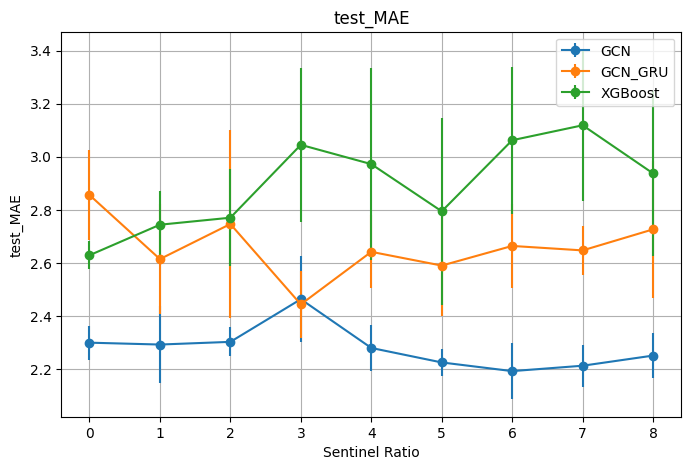

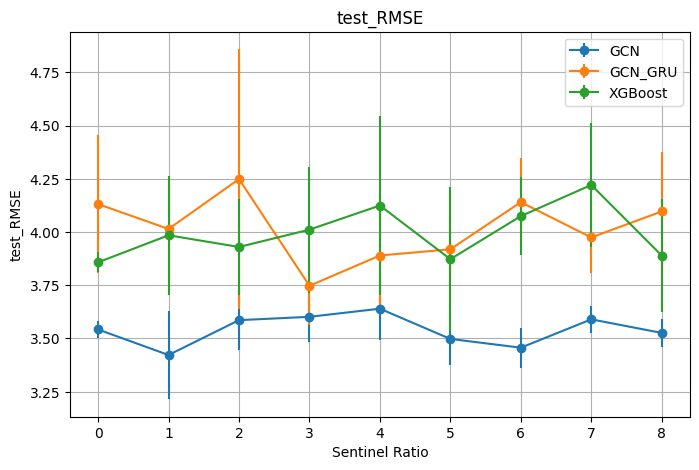

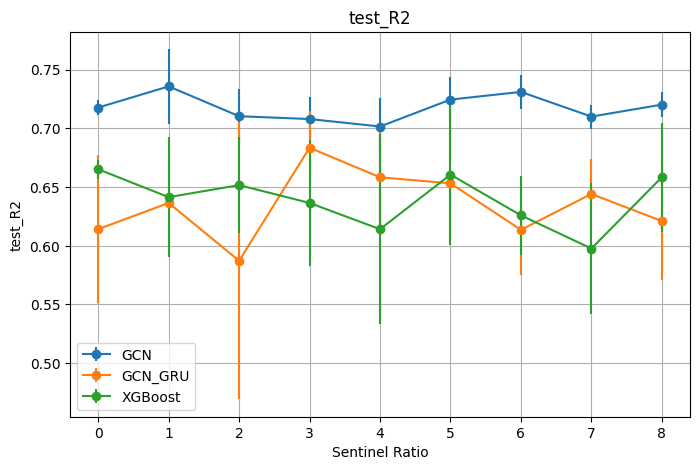

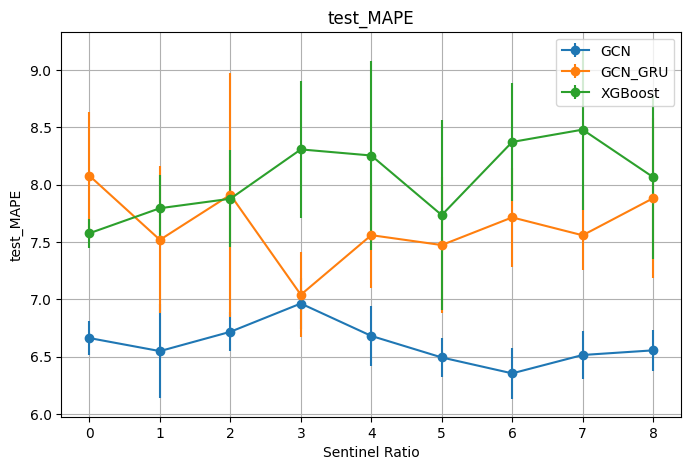

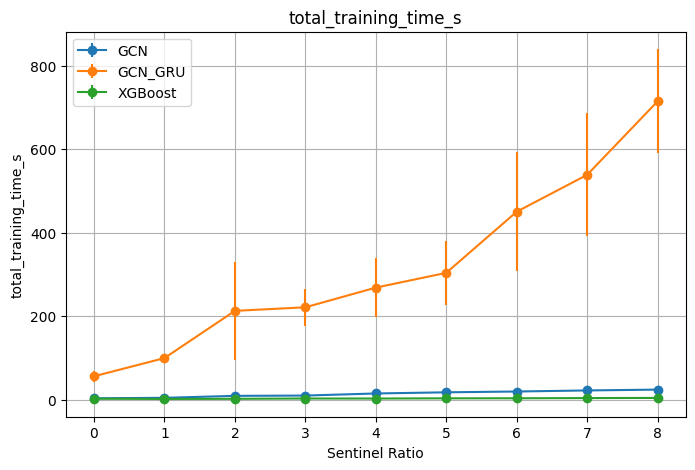

In [18]:
# ============================================================
# GRÁFICAS SENTINEL RATIO
# ============================================================

import matplotlib.pyplot as plt

sentinel_df = agg_df[
    agg_df["experiment_type"] == "sentinel_ratio"
]

for metric in [
    "test_MAE",
    "test_RMSE",
    "test_R2",
    "test_MAPE",
    "total_training_time_s"
]:

    plt.figure(figsize=(8,5))

    for model_name in sentinel_df["model"].unique():

        tmp = sentinel_df[
            sentinel_df["model"] == model_name
        ].sort_values("sentinel_ratio")

        plt.errorbar(
            tmp["sentinel_ratio"],
            tmp[f"{metric}_mean"],
            yerr=tmp[f"{metric}_std"],
            marker="o",
            label=model_name
        )

    plt.title(metric)
    plt.xlabel("Sentinel Ratio")
    plt.ylabel(metric)

    plt.legend()

    plt.grid(True)

    plt.show()

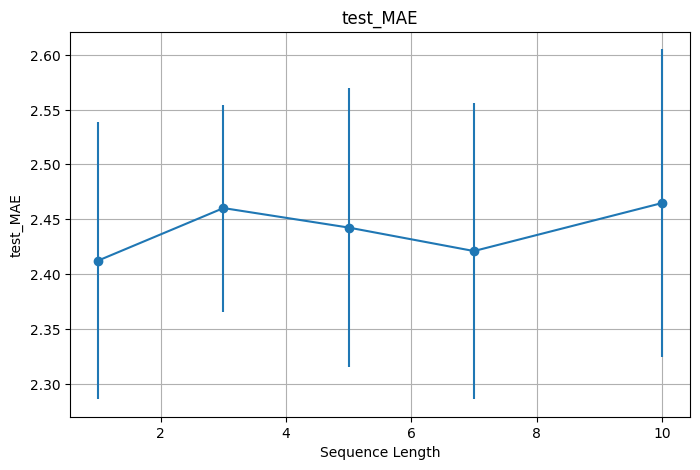

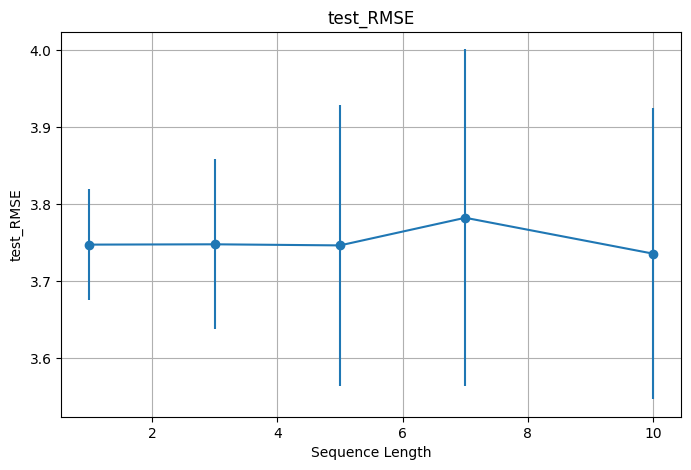

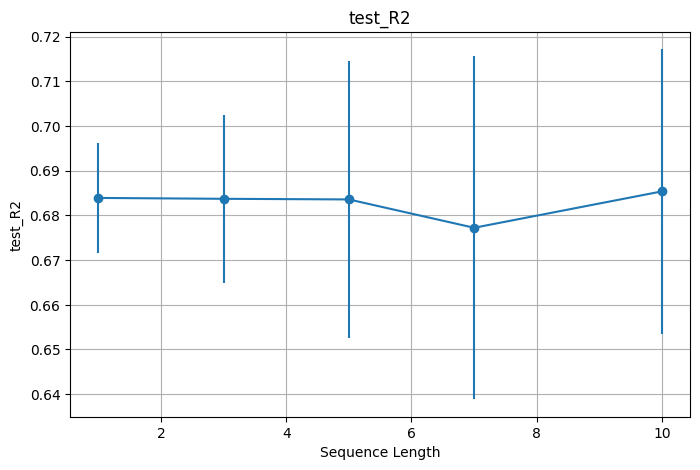

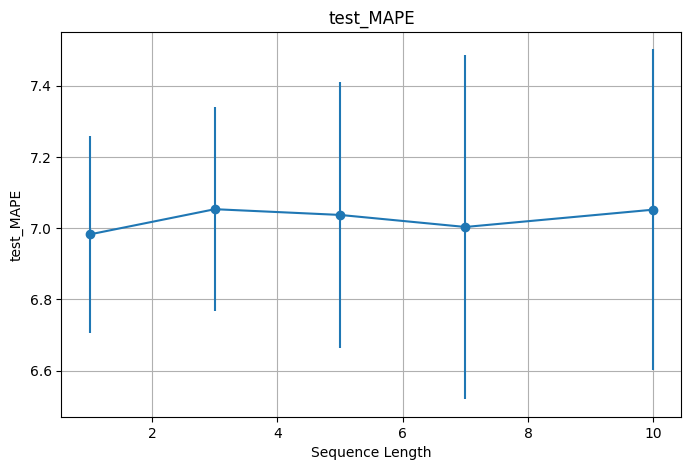

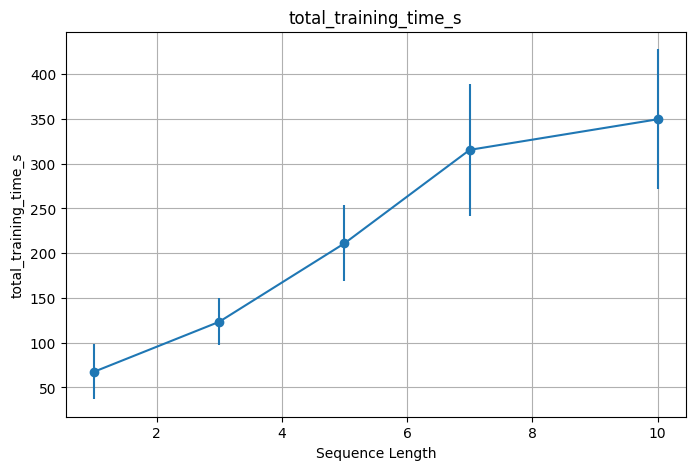

In [19]:
# ============================================================
# GRÁFICAS SEQ LEN
# ============================================================

seq_df = agg_df[
    agg_df["experiment_type"] == "seq_len"
]

for metric in [
    "test_MAE",
    "test_RMSE",
    "test_R2",
    "test_MAPE",
    "total_training_time_s"

]:

    plt.figure(figsize=(8,5))

    plt.errorbar(
        seq_df["seq_len"],
        seq_df[f"{metric}_mean"],
        yerr=seq_df[f"{metric}_std"],
        marker="o"
    )

    plt.title(metric)
    plt.xlabel("Sequence Length")
    plt.ylabel(metric)

    plt.grid(True)

    plt.show()

,model,experiment_type,sentinel_ratio,seq_len,seed,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE
160,XGBoost,final_comparison,3,5,42,1.383804,65,0.021289,3.451390,4.353035,0.573702,9.152512
161,XGBoost,final_comparison,3,5,123,1.326208,82,0.016173,2.782421,3.664797,0.697845,7.680283
162,XGBoost,final_comparison,3,5,2024,3.368383,237,0.014213,2.793048,3.807115,0.673922,7.870838
163,XGBoost,final_comparison,3,5,7,1.574015,106,0.014849,2.971168,3.956905,0.647758,8.189857
164,XGBoost,final_comparison,3,5,99,2.596299,192,0.013522,3.224648,4.273765,0.589086,8.641788


Número de ejecuciones finales: 25
model
XGBoost      5
GRU          5
GCN          5
GraphSAGE    5
GCN_GRU      5
Name: count, dtype: int64


,model,test_MAE_mean,test_MAE_std,test_RMSE_mean,test_RMSE_std,test_R2_mean,test_R2_std,test_MAPE_mean,test_MAPE_std,total_training_time_s_mean,total_training_time_s_std
0,GCN,2.462643,0.162109,3.601451,0.116464,0.707956,0.018557,6.961984,0.224393,9.814182,3.266045
1,GCN_GRU,2.446097,0.130017,3.749542,0.181390,0.683117,0.030799,7.045175,0.374061,221.787911,45.417584
2,GRU,2.746842,0.150194,3.924669,0.380467,0.650869,0.069775,7.730994,0.429225,566.910452,31.036946
3,GraphSAGE,2.330003,0.050113,3.602804,0.113125,0.707751,0.018243,6.814863,0.071228,12.611873,4.433132
4,XGBoost,3.044535,0.289527,4.011123,0.295967,0.636463,0.053577,8.307056,0.596596,2.049742,0.898725


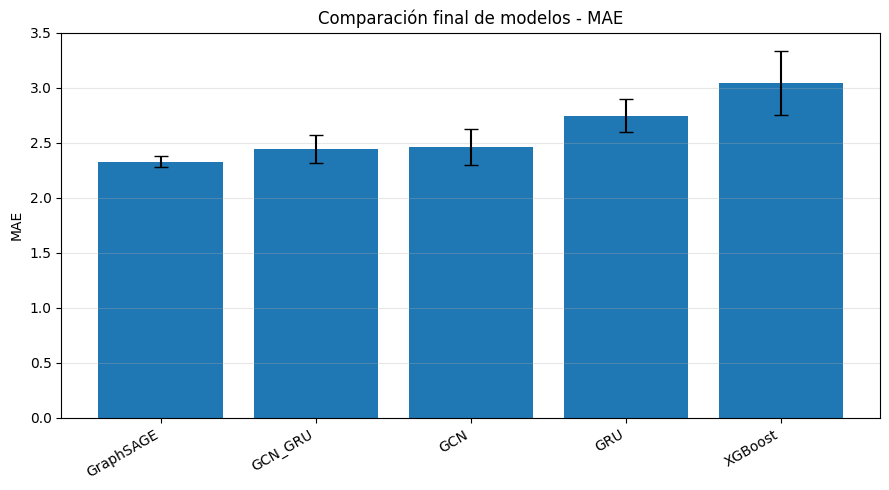

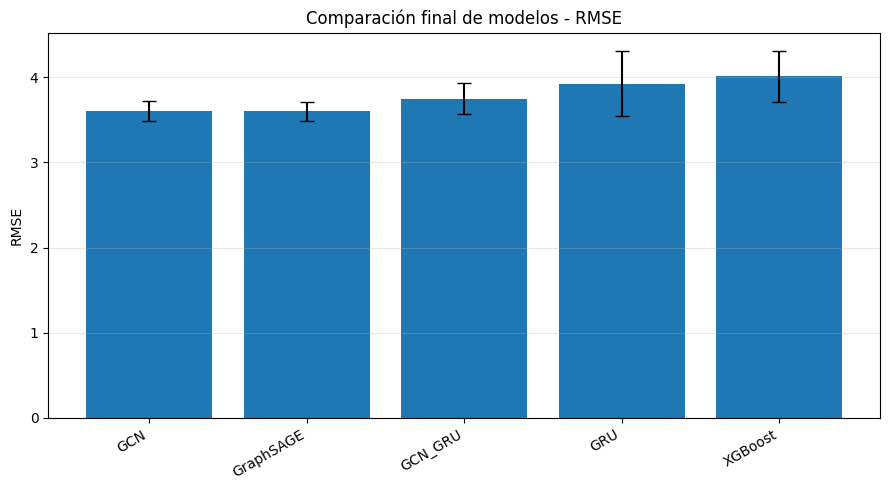

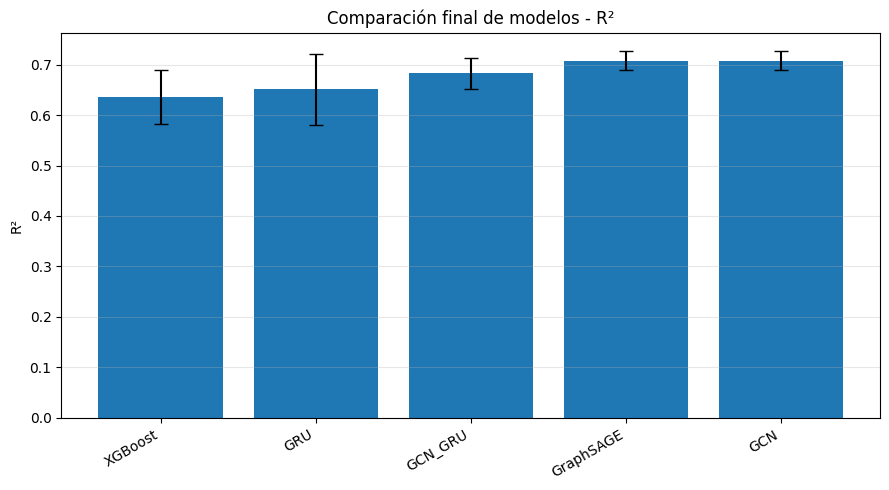

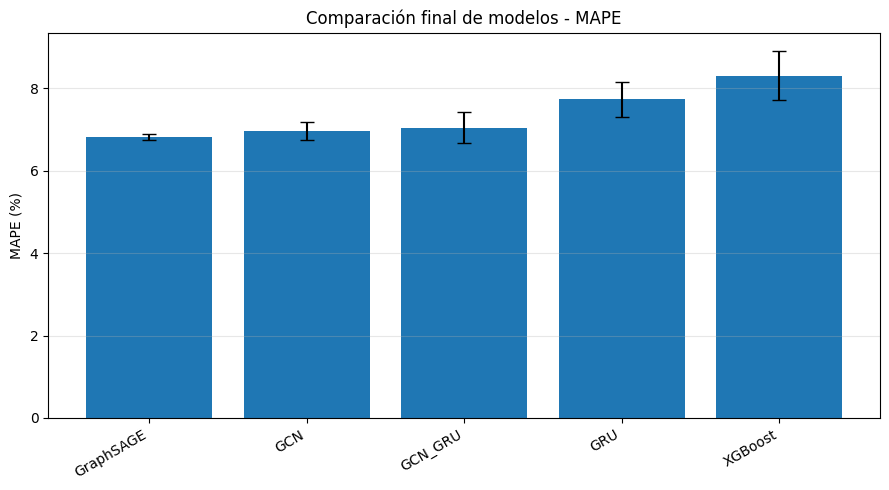

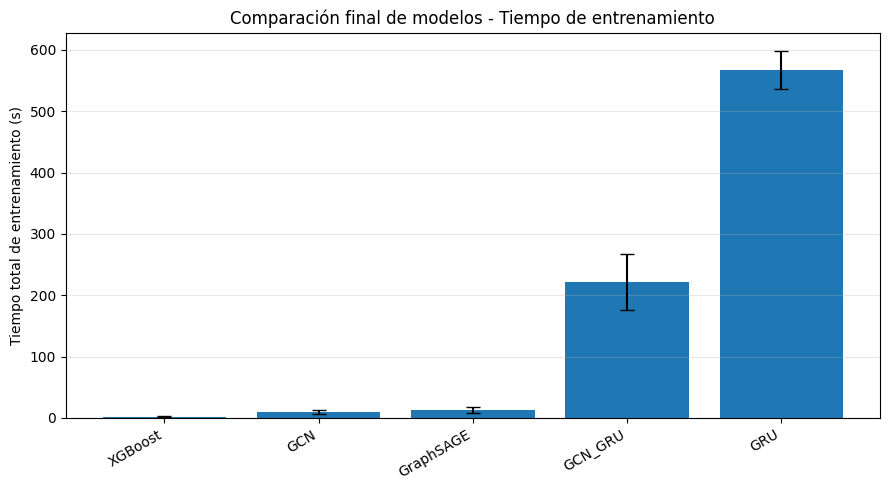

In [23]:
# ============================================================
# 14. VISUALIZACIÓN DEL EXPERIMENTO FINAL
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar resultados detallados
results_df = pd.read_csv(DETAILED_RESULTS_PATH)

# Filtrar solo comparación final
final_df = results_df[
    results_df["experiment_type"] == "final_comparison"
].copy()

display(final_df.head())

print("Número de ejecuciones finales:", len(final_df))
print(final_df["model"].value_counts())
# ============================================================
# AGREGAR RESULTADOS POR MODELO
# ============================================================

metrics = [
    "test_MAE",
    "test_RMSE",
    "test_R2",
    "test_MAPE",
    "total_training_time_s"
]

final_agg = (
    final_df
    .groupby("model")[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

final_agg.columns = [
    "_".join(col).strip("_")
    for col in final_agg.columns
]

display(final_agg)

# ============================================================
# FUNCIÓN PARA GRAFICAR MÉTRICAS
# ============================================================

def plot_final_metric(
    df,
    metric,
    ylabel,
    title
):
    df_plot = df.sort_values(f"{metric}_mean")

    plt.figure(figsize=(9, 5))

    plt.bar(
        df_plot["model"],
        df_plot[f"{metric}_mean"],
        yerr=df_plot[f"{metric}_std"],
        capsize=5
    )

    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# GRÁFICAS DE MÉTRICAS
# ============================================================

plot_final_metric(
    final_agg,
    metric="test_MAE",
    ylabel="MAE",
    title="Comparación final de modelos - MAE"
)

plot_final_metric(
    final_agg,
    metric="test_RMSE",
    ylabel="RMSE",
    title="Comparación final de modelos - RMSE"
)

plot_final_metric(
    final_agg,
    metric="test_R2",
    ylabel="R²",
    title="Comparación final de modelos - R²"
)

plot_final_metric(
    final_agg,
    metric="test_MAPE",
    ylabel="MAPE (%)",
    title="Comparación final de modelos - MAPE"
)

plot_final_metric(
    final_agg,
    metric="total_training_time_s",
    ylabel="Tiempo total de entrenamiento (s)",
    title="Comparación final de modelos - Tiempo de entrenamiento"
)